# Predicting Irrigation Need 

#### Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Irrigation Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

#### Files
* train.csv - the training set, with Irrigation_Need as target
* test.csv - the test set, used to predict the category for Irrigation_Need
* sample_submission.csv - a sample submission file in the correct format

https://www.kaggle.com/competitions/playground-series-s6e4/overview

In [164]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

In [165]:
base_dir = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
base_dir

'd:\\Codes\\Artificial_Intelligence\\Machine_Learning\\Machine-Learning-With-Scikit-Learn\\Projects'

In [166]:
# Reading training and test datasets
print('Reading the train and test datasets .....')
train_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/train.csv')
test_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/test.csv')
print('Successfully read the train and test datasets.')

Reading the train and test datasets .....
Successfully read the train and test datasets.


In [167]:
print(f'Size of train dataset: {train_df.shape}')
print(f'Size of test dataset: {test_df.shape}')

Size of train dataset: (630000, 21)
Size of test dataset: (270000, 20)


In [168]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [169]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [170]:
# Checking for null values
train_df[train_df.isnull()==1].count()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [171]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [172]:
print('Unique values of categorical colunmns:\n')
for i, col in enumerate(train_df.select_dtypes(include='object')):
    print(f'{i}.  {col}: {train_df[col].unique()}')

Unique values of categorical colunmns:

0.  Soil_Type: ['Loamy' 'Clay' 'Sandy' 'Silt']
1.  Crop_Type: ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
2.  Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
3.  Season: ['Zaid' 'Kharif' 'Rabi']
4.  Irrigation_Type: ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
5.  Water_Source: ['Rainwater' 'River' 'Reservoir' 'Groundwater']
6.  Mulching_Used: ['No' 'Yes']
7.  Region: ['East' 'South' 'North' 'West' 'Central']
8.  Irrigation_Need: ['Low' 'Medium' 'High']


In [173]:
# Checking for the test_df
print(f'Test info:\n{test_df.info()}\n\n')
print(f'Test describe:\n{test_df.describe()}\n\n')
print(f'Test head:\n{test_df.head()}\n\n')

# Checking for null values
print(train_df[train_df.isnull()==1].count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [174]:
train_df['Irrigation_Need'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [175]:
# train_df.select_dtypes(include='number').corr()['Irrigation_Need']

## Visualizing the dataset

In [176]:
from scipy.stats import skew, kurtosis

In [177]:
df = train_df.sample(1000)

In [178]:
# ── Global style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F6',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.linestyle':   '--',
    'font.size':        11,
})

PALETTE = {
    'Low':    '#1D9E75',   # green
    'Medium': '#BA7517',   # amber
    'High':   '#E24B4A',   # red
}
ORDER = ['Low', 'Medium', 'High']

In [179]:
# ── Column groups ─────────────────────────────────────────
NUMERIC = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C', 'Humidity',
    'Rainfall_mm', 'Sunlight_Hours', 'Field_Area_hectare',
    'Previous_Irrigation_mm'
]
CATEGORICAL = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
    'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'
]
TARGET = 'Irrigation_Need'

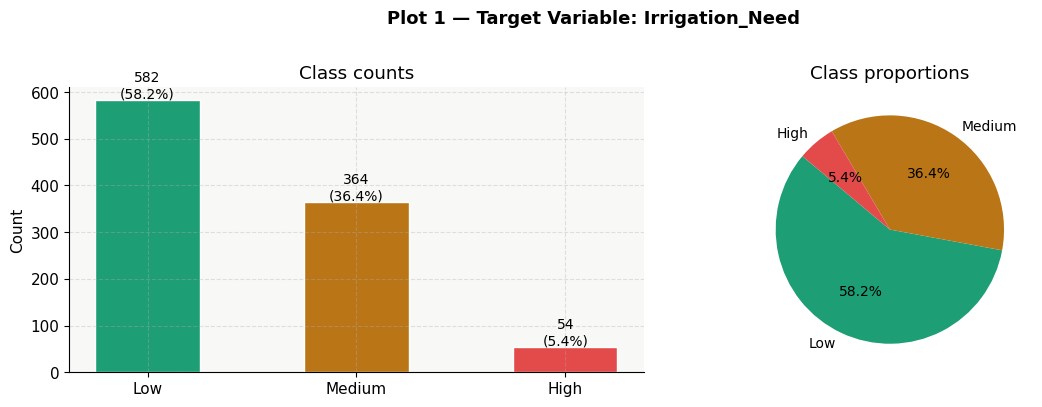

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Plot 1 — Target Variable: Irrigation_Need', fontsize=13, fontweight='bold', y=1.01)

counts = df[TARGET].value_counts()[ORDER]
pcts   = df[TARGET].value_counts(normalize=True)[ORDER] * 100

axes[0].bar(ORDER, counts, color=[PALETTE[c] for c in ORDER], width=0.5, edgecolor='white')
for i, (n, p) in enumerate(zip(counts, pcts)):
    axes[0].text(i, n + 5, f'{n}\n({p:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class counts')
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=ORDER, colors=[PALETTE[c] for c in ORDER],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Class proportions')

plt.tight_layout()
plt.savefig('plot1_target.png', dpi=150, bbox_inches='tight')
plt.show()

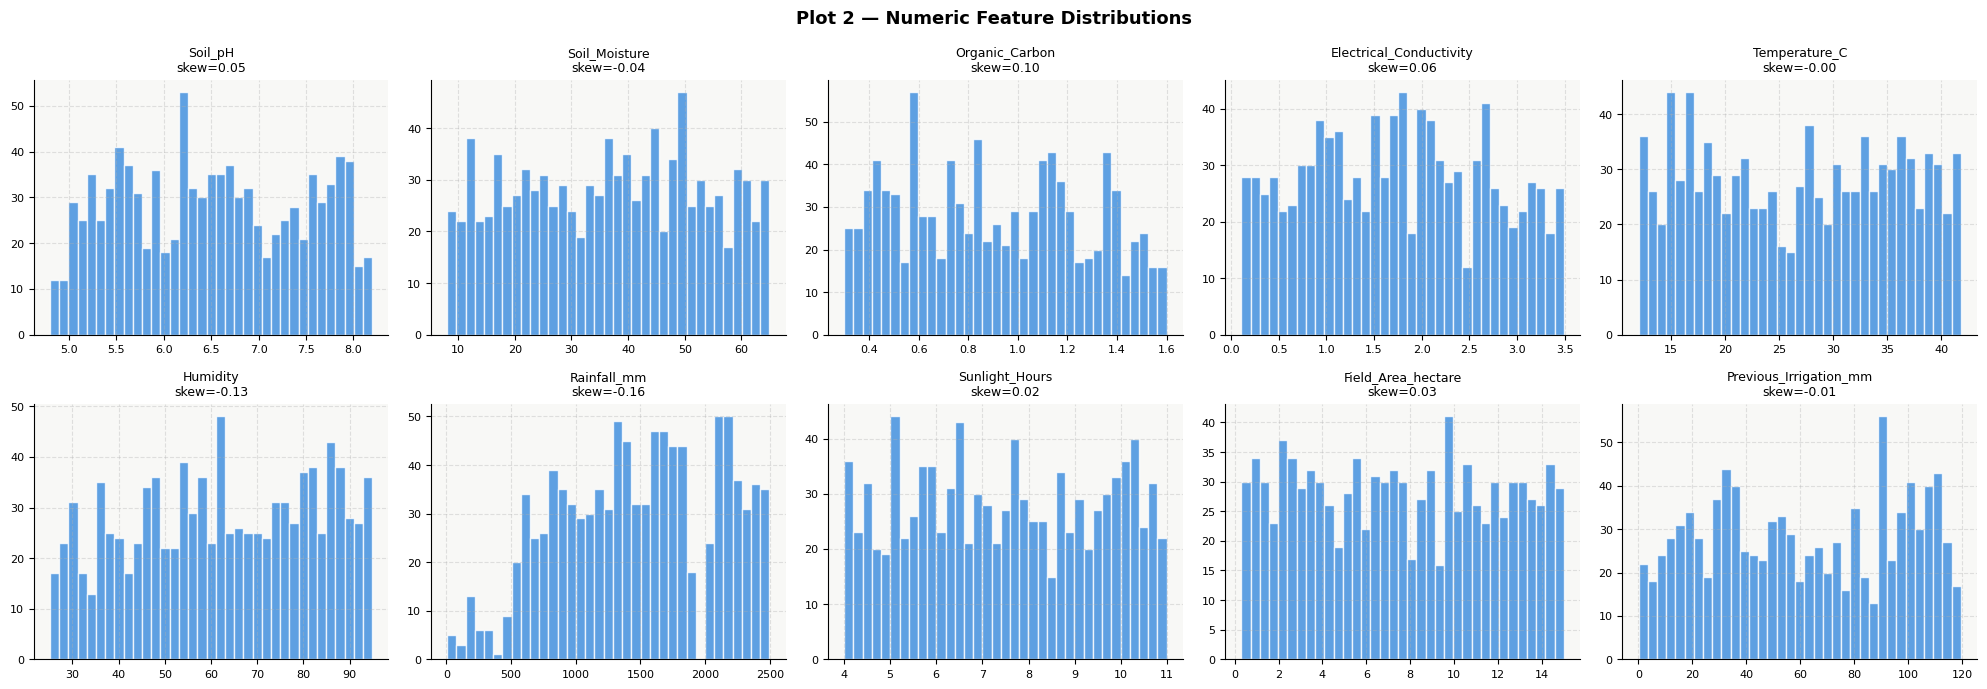


── Features with |skew| > 1 (log-transform candidates) ──


In [181]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Plot 2 — Numeric Feature Distributions', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    sk = skew(df[col].dropna())
    color = '#E24B4A' if abs(sk) > 1 else '#378ADD'
    axes[i].hist(df[col].dropna(), bins=35, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{col}\nskew={sk:.2f}', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('plot2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick print — which features need log transform
print("\n── Features with |skew| > 1 (log-transform candidates) ──")
for col in NUMERIC:
    s = skew(df[col].dropna())
    if abs(s) > 1:
        print(f"  {col:35s}  skew = {s:+.2f}")

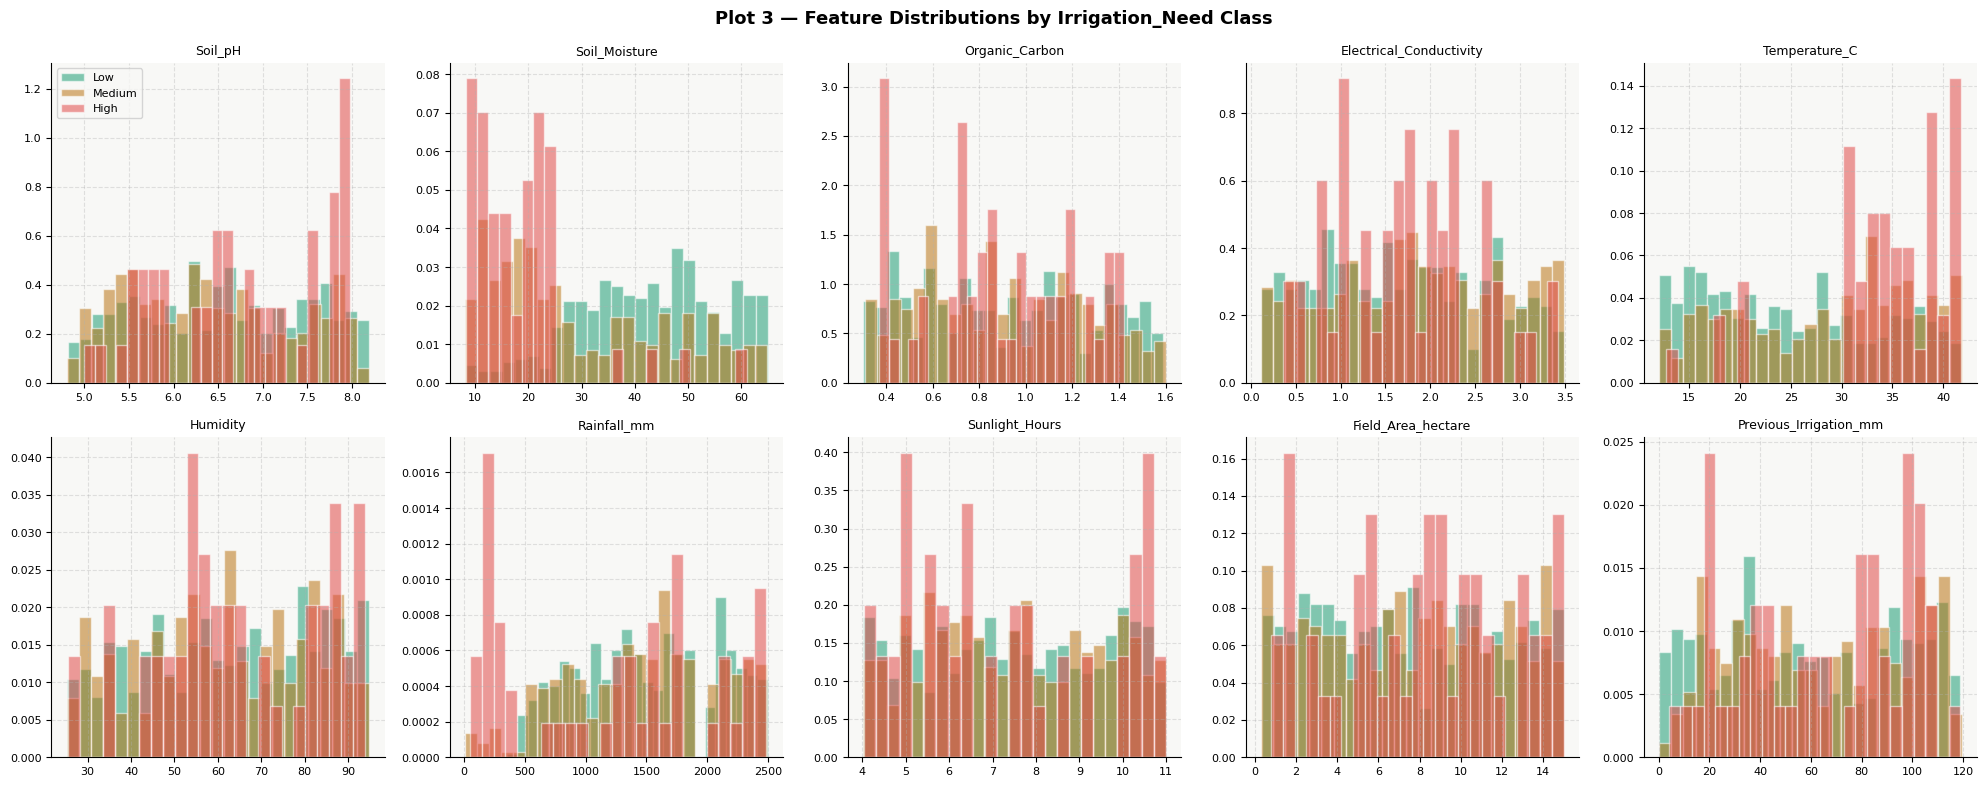

In [182]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Plot 3 — Feature Distributions by Irrigation_Need Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    for cls in ORDER:
        vals = df[df[TARGET] == cls][col].dropna()
        axes[i].hist(vals, bins=25, alpha=0.55, label=cls,
                     color=PALETTE[cls], edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot3_class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


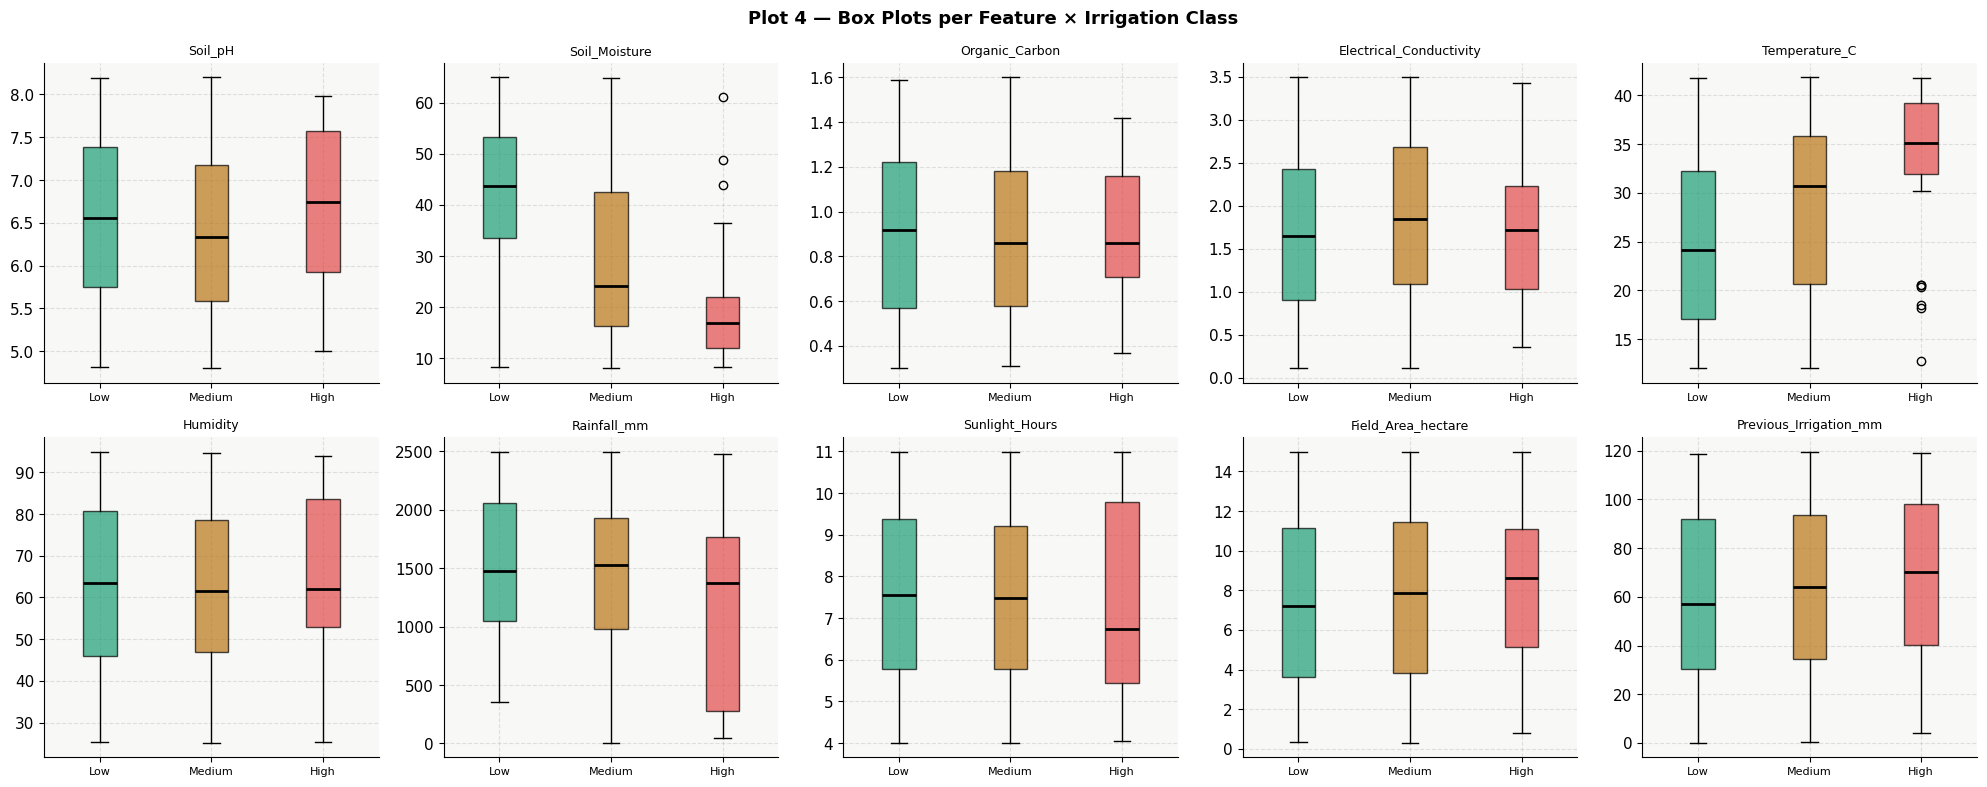


── Outlier summary (IQR method) ──
  Soil_pH                              outliers =    0  (0.0%)
  Soil_Moisture                        outliers =    0  (0.0%)
  Organic_Carbon                       outliers =    0  (0.0%)
  Electrical_Conductivity              outliers =    0  (0.0%)
  Temperature_C                        outliers =    0  (0.0%)
  Humidity                             outliers =    0  (0.0%)
  Rainfall_mm                          outliers =    0  (0.0%)
  Sunlight_Hours                       outliers =    0  (0.0%)
  Field_Area_hectare                   outliers =    0  (0.0%)
  Previous_Irrigation_mm               outliers =    0  (0.0%)


In [183]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Plot 4 — Box Plots per Feature × Irrigation Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    data_by_class = [df[df[TARGET] == cls][col].dropna() for cls in ORDER]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(ORDER, fontsize=8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print outlier summary
print("\n── Outlier summary (IQR method) ──")
for col in NUMERIC:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:35s}  outliers = {n_out:4d}  ({pct:.1f}%)")

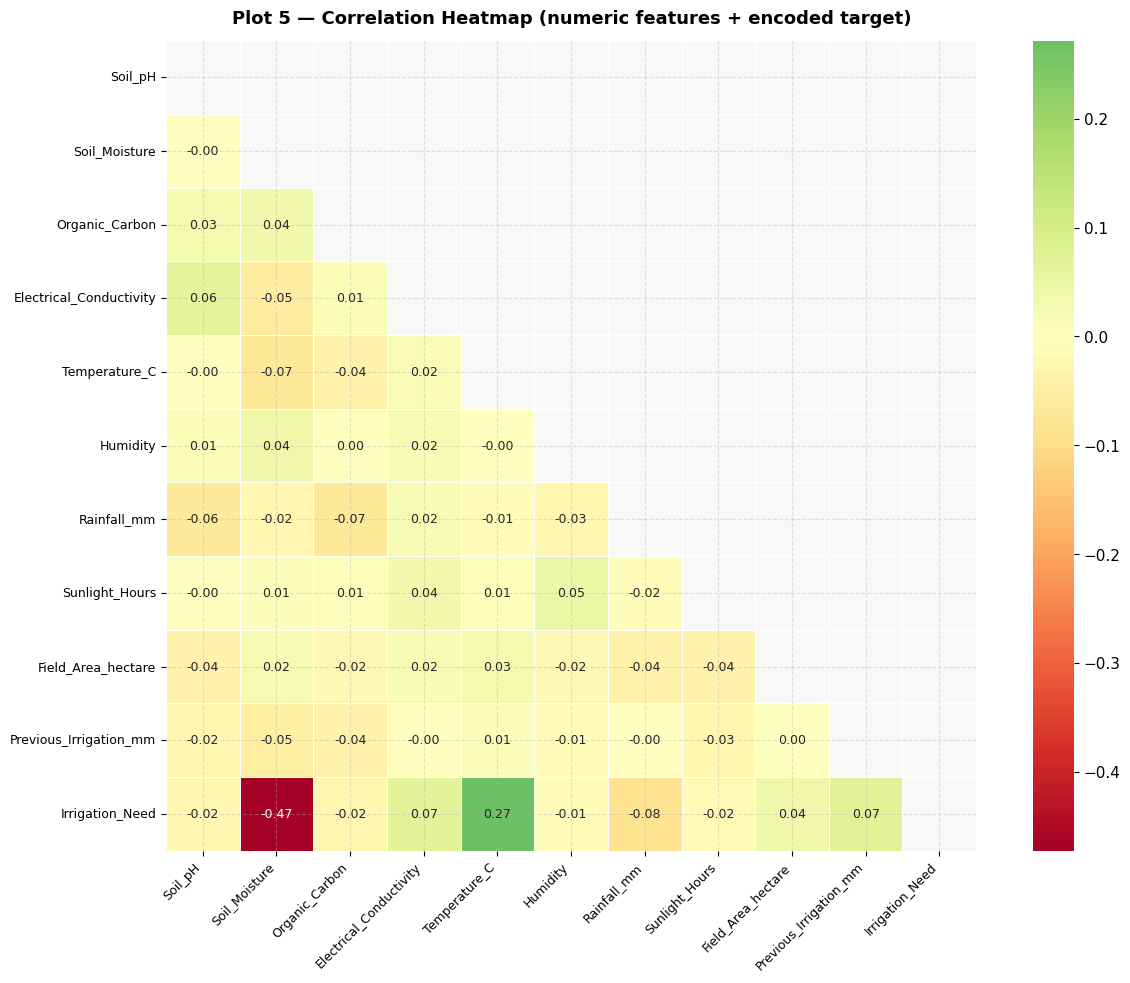

In [184]:
df_enc = df[NUMERIC + [TARGET]].copy()
df_enc[TARGET] = df_enc[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Plot 5 — Correlation Heatmap (numeric features + encoded target)', fontsize=13, fontweight='bold')

corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

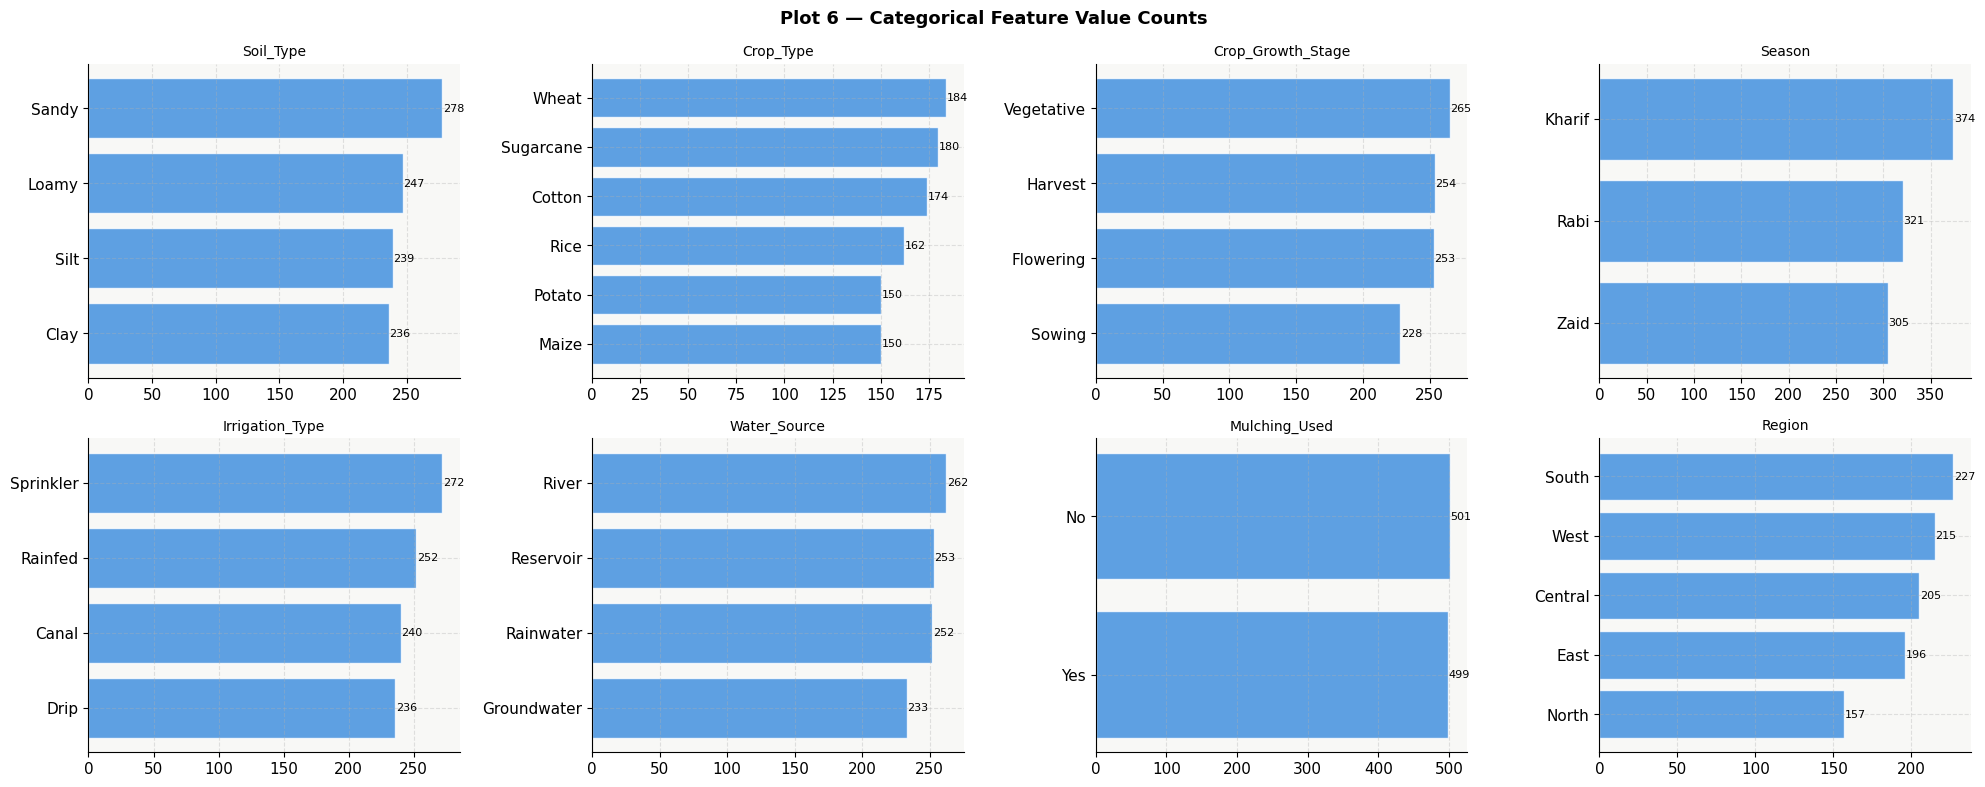

In [185]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Plot 6 — Categorical Feature Value Counts', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color='#378ADD', alpha=0.8, edgecolor='white')
    for j, (idx, val) in enumerate(zip(vc.index, vc.values)):
        axes[i].text(val + 0.5, j, str(val), va='center', fontsize=8)
    axes[i].set_title(col, fontsize=10)
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('plot6_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

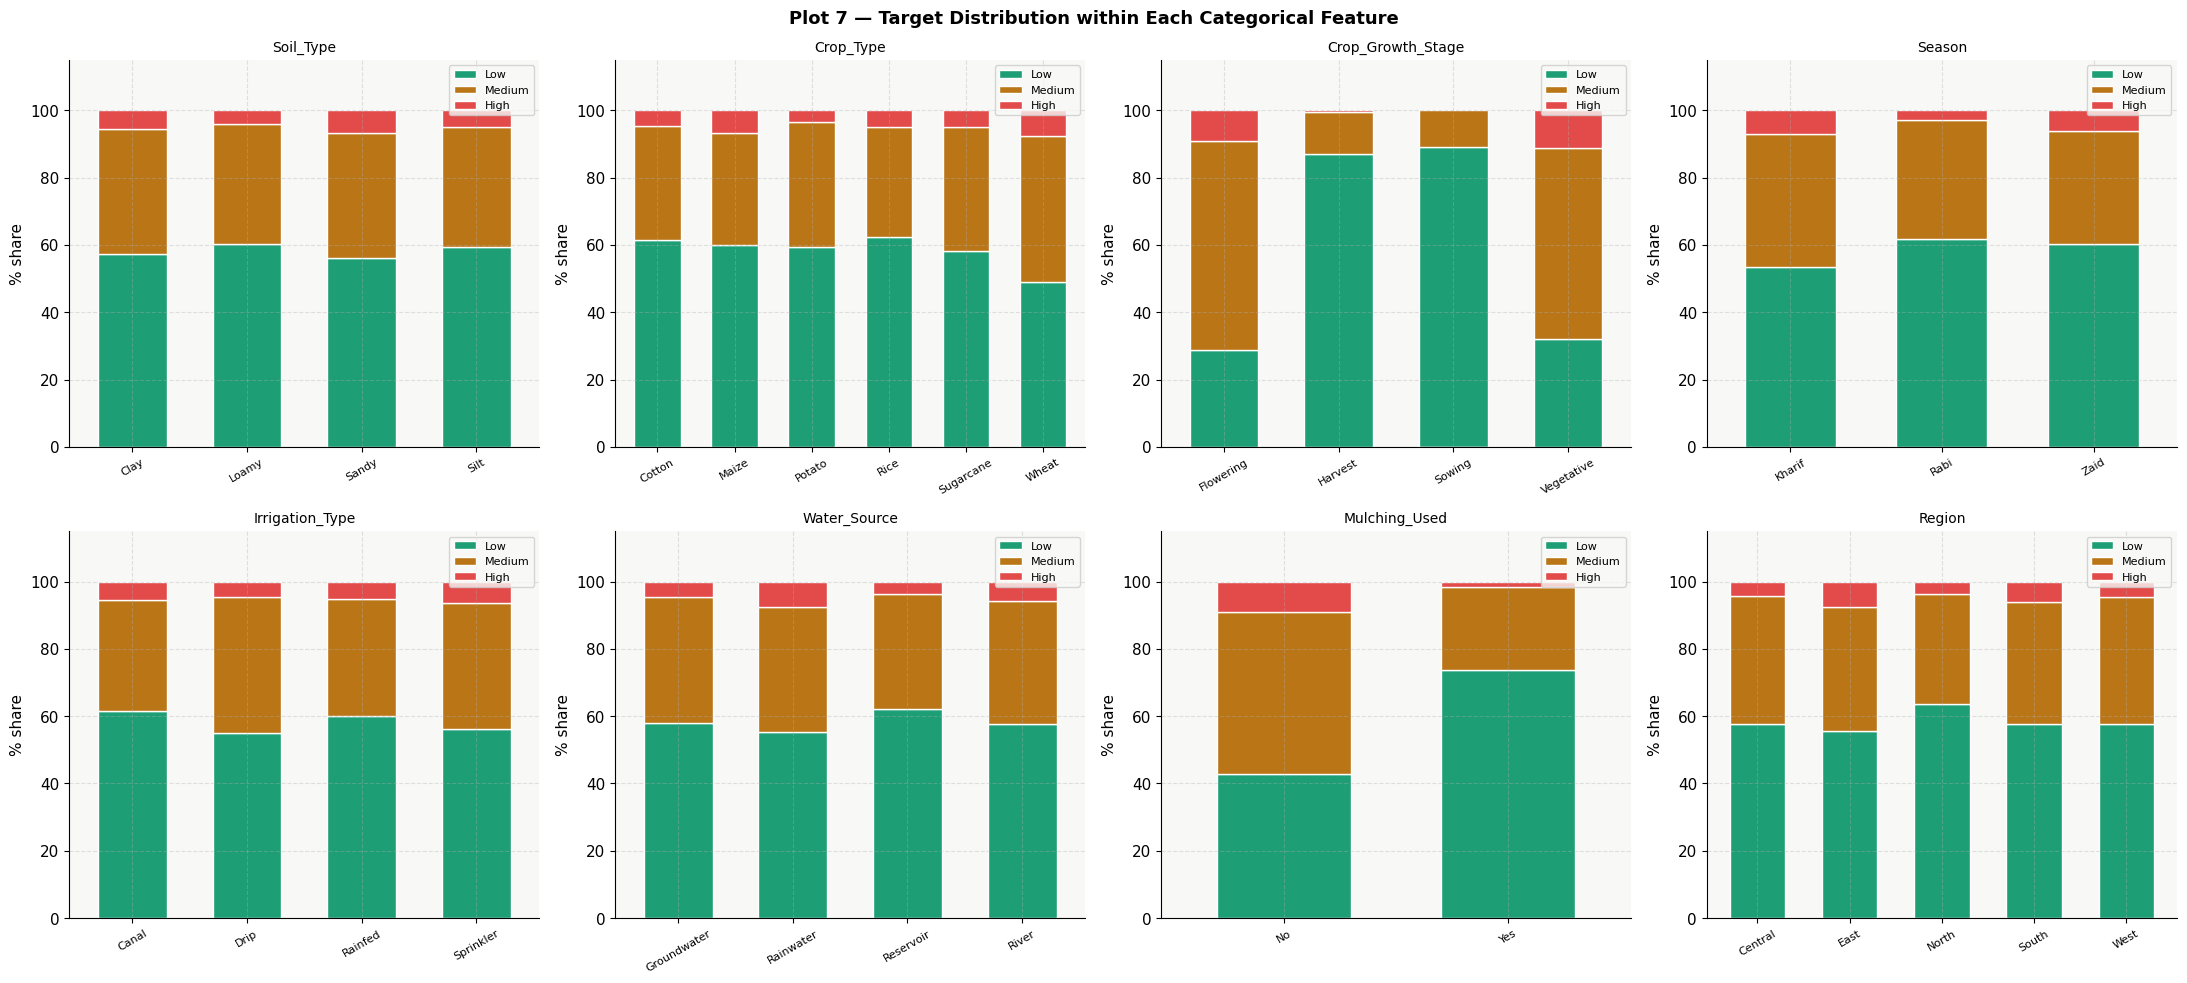

In [186]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Plot 7 — Target Distribution within Each Categorical Feature', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    ct = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[i],
                color=[PALETTE[c] for c in ORDER], edgecolor='white', width=0.6)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% share')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].legend(ORDER, fontsize=8, loc='upper right')
    axes[i].set_ylim(0, 115)

plt.tight_layout()
plt.savefig('plot7_cat_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [187]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_df = missing_pct[missing_pct > 0]

if len(missing_df) == 0:
    print("\n✓ No missing values found in dataset.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.5)))
    fig.suptitle('Plot 8 — Missing Value Analysis', fontsize=13, fontweight='bold')
    colors = ['#E24B4A' if p > 30 else '#BA7517' if p > 10 else '#1D9E75'
              for p in missing_df.values]
    ax.barh(missing_df.index, missing_df.values, color=colors, edgecolor='white')
    ax.axvline(30, color='#E24B4A', linestyle='--', alpha=0.7, label='30% threshold')
    ax.axvline(10, color='#BA7517', linestyle='--', alpha=0.7, label='10% threshold')
    ax.set_xlabel('% Missing')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plot8_missing.png', dpi=150, bbox_inches='tight')
    plt.show()

# Always print the full table
print("\n── Missing value summary ──")
print(missing_pct.to_string())


✓ No missing values found in dataset.

── Missing value summary ──
id                         0.0
Crop_Type                  0.0
Region                     0.0
Previous_Irrigation_mm     0.0
Mulching_Used              0.0
Field_Area_hectare         0.0
Water_Source               0.0
Irrigation_Type            0.0
Season                     0.0
Crop_Growth_Stage          0.0
Wind_Speed_kmh             0.0
Soil_Type                  0.0
Sunlight_Hours             0.0
Rainfall_mm                0.0
Humidity                   0.0
Temperature_C              0.0
Electrical_Conductivity    0.0
Organic_Carbon             0.0
Soil_Moisture              0.0
Soil_pH                    0.0
Irrigation_Need            0.0


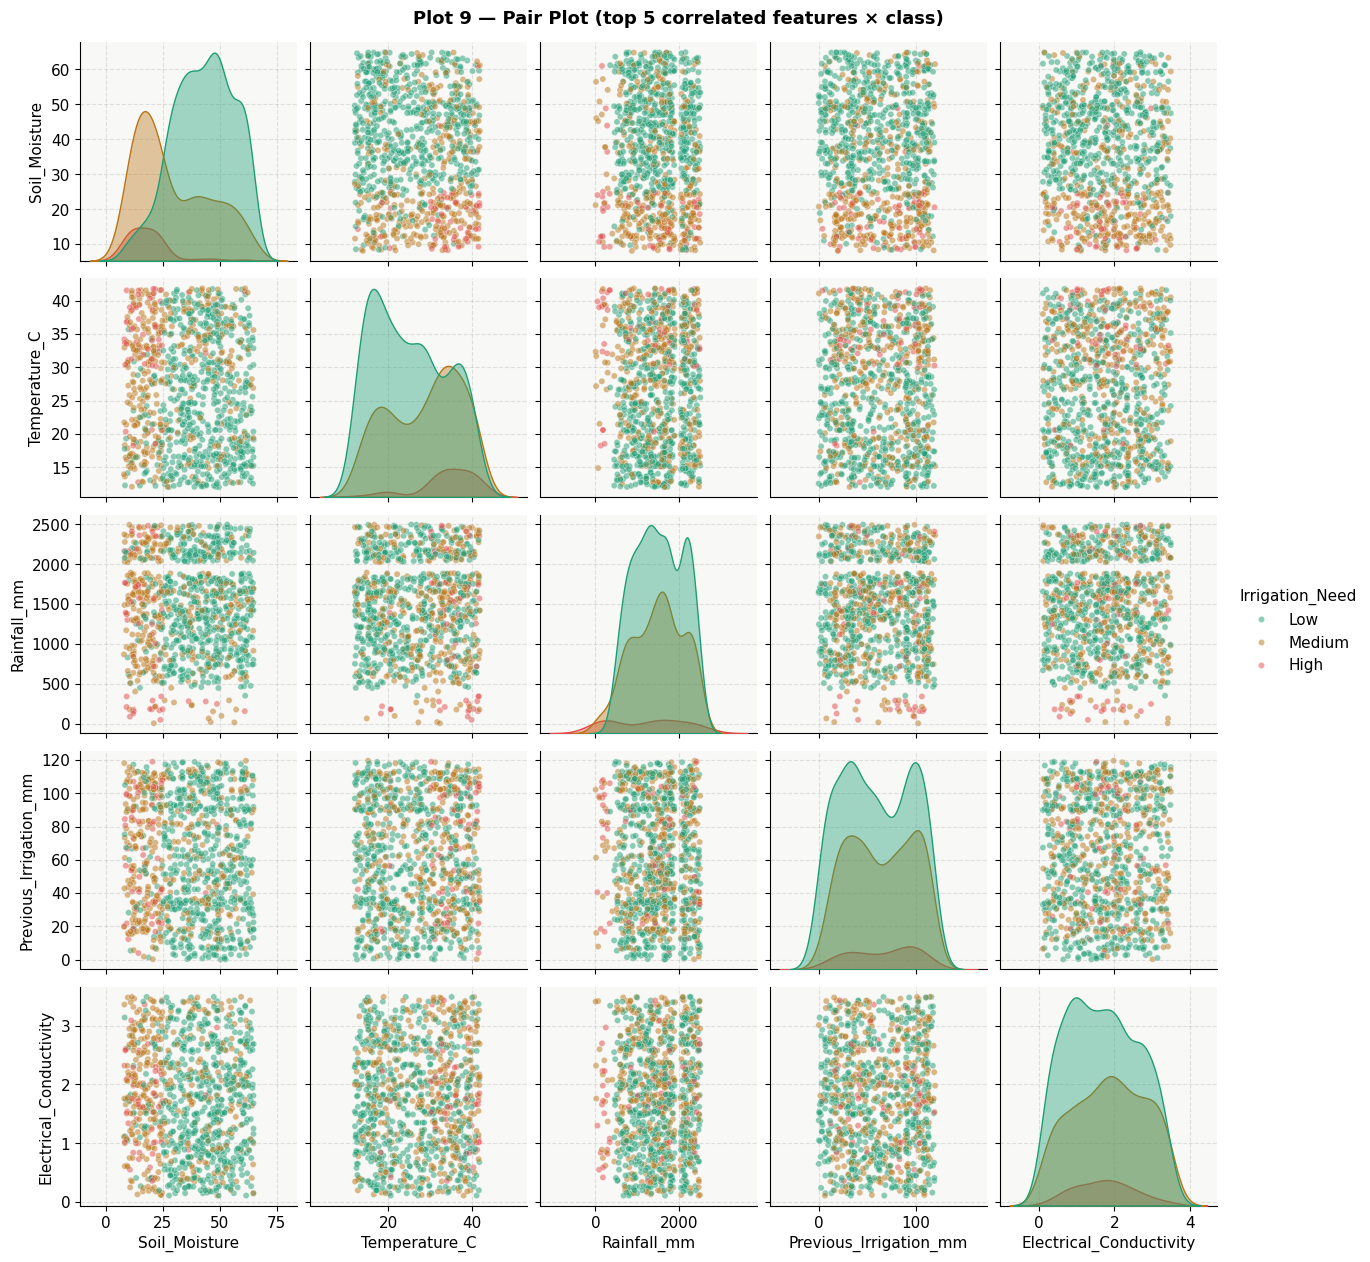

In [188]:
# Use top 5 correlated features with target for clarity
df_enc_tmp = df[NUMERIC].copy()
target_enc = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
correlations_with_target = df_enc_tmp.corrwith(target_enc).abs().sort_values(ascending=False)
top5 = correlations_with_target.head(5).index.tolist()

pair_df = df[top5 + [TARGET]].copy()
g = sns.pairplot(pair_df, hue=TARGET, hue_order=ORDER,
                 palette=PALETTE, diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('Plot 9 — Pair Plot (top 5 correlated features × class)', y=1.01, fontsize=13, fontweight='bold')
plt.savefig('plot9_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\itspr\AppData\Local\Temp\ipykernel_17492\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_17492\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_17492\1692261657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
C:\Users\itspr\AppData\Local\Temp\ipykernel_17492\1692261657.py:6: FutureWarning: 

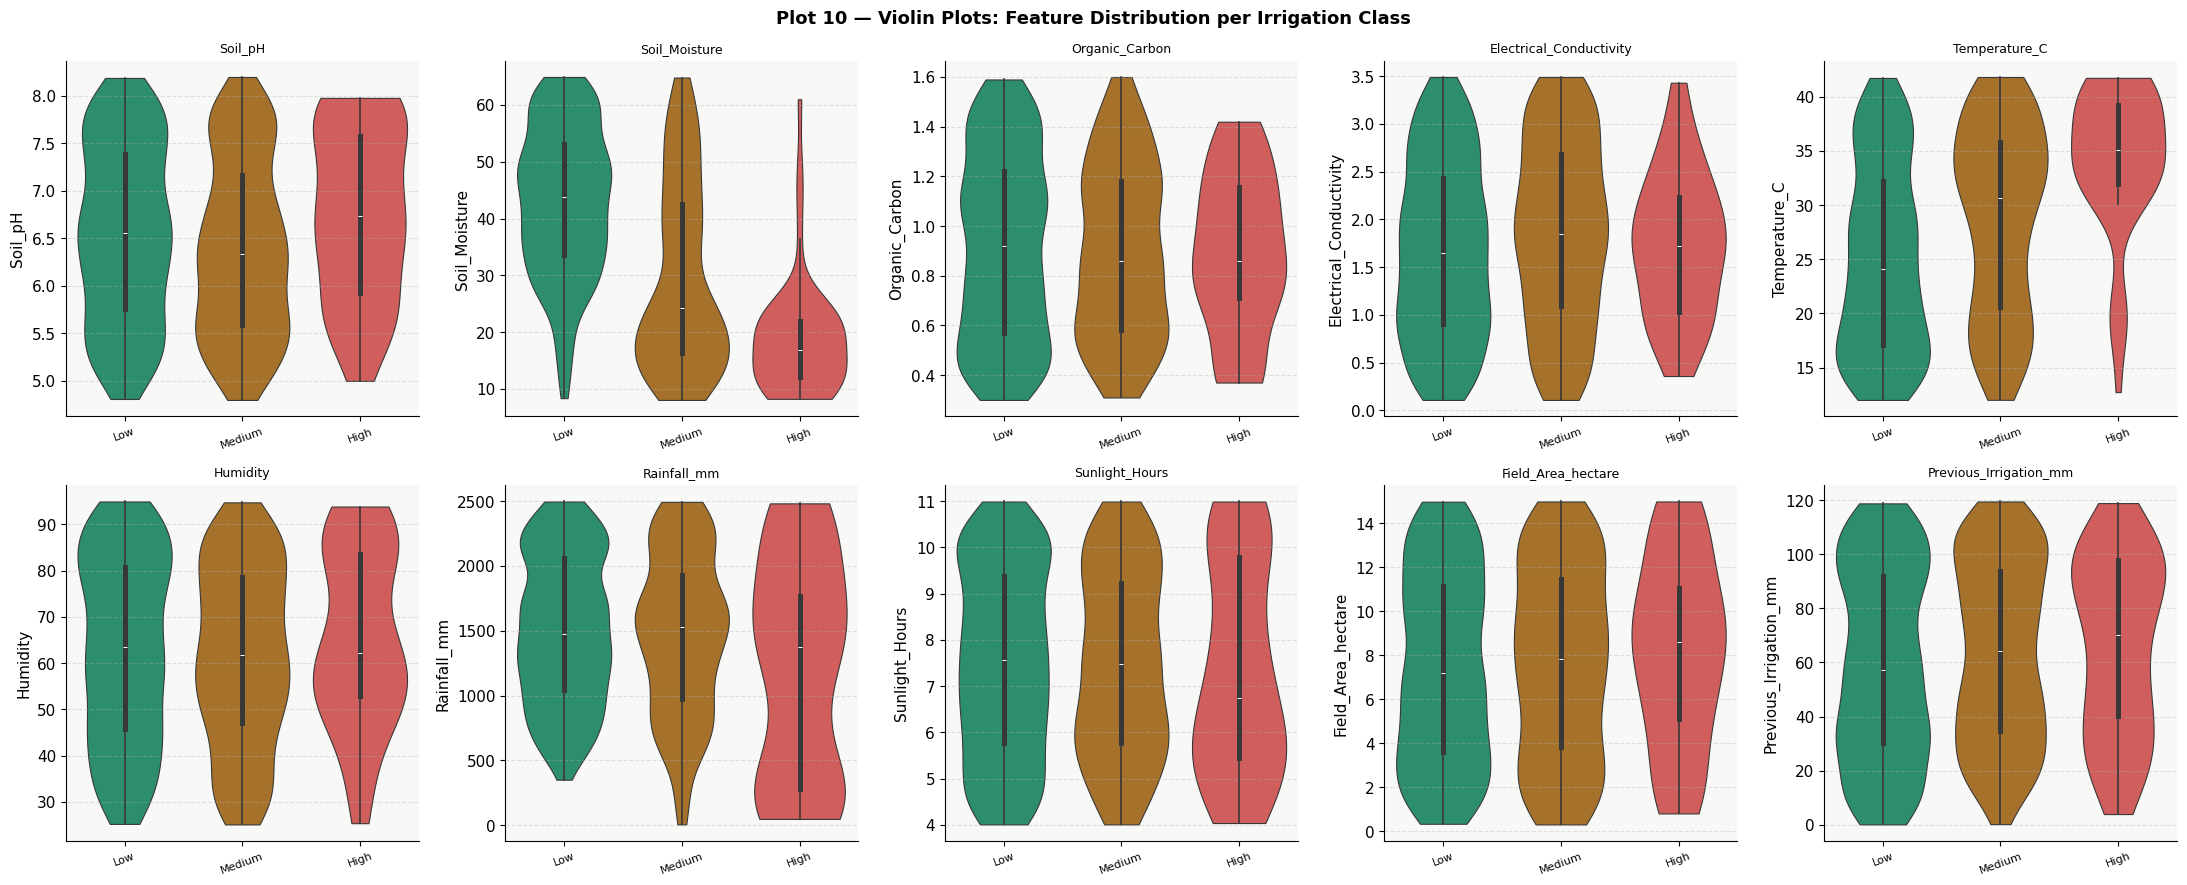

In [189]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Plot 10 — Violin Plots: Feature Distribution per Irrigation Class', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    sns.violinplot(data=df, x=TARGET, y=col, order=ORDER,
                   palette=PALETTE, ax=axes[i], inner='box',
                   cut=0, linewidth=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout()
plt.savefig('plot10_violin.png', dpi=150, bbox_inches='tight')
plt.show()

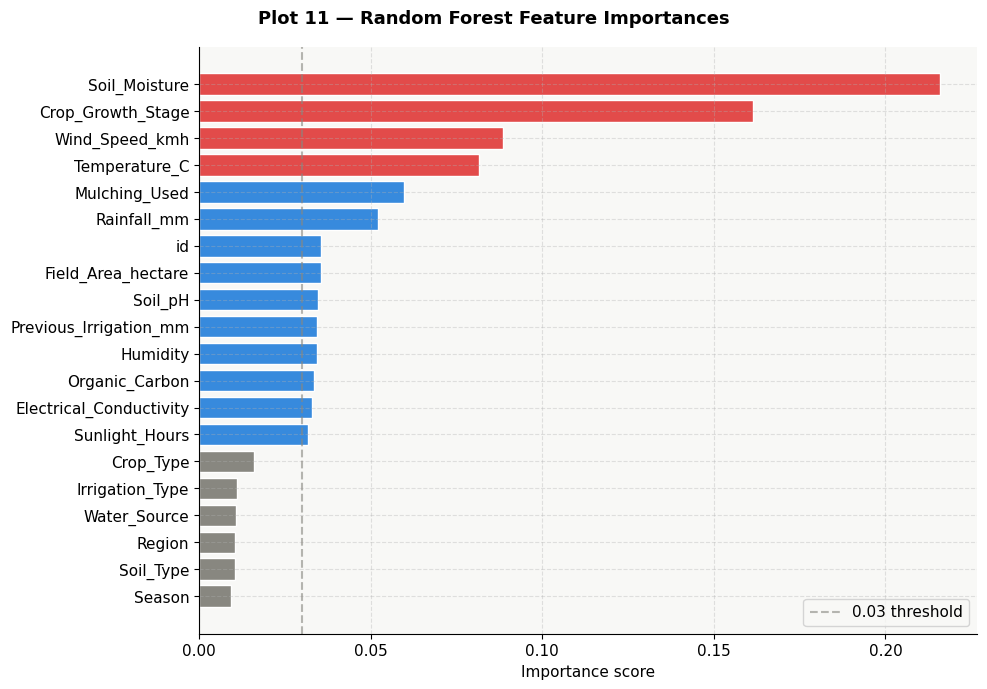


── Feature importances (descending) ──
Soil_Moisture              0.215906
Crop_Growth_Stage          0.161312
Wind_Speed_kmh             0.088537
Temperature_C              0.081598
Mulching_Used              0.059785
Rainfall_mm                0.052140
id                         0.035652
Field_Area_hectare         0.035480
Soil_pH                    0.034557
Previous_Irrigation_mm     0.034470
Humidity                   0.034239
Organic_Carbon             0.033499
Electrical_Conductivity    0.032793
Sunlight_Hours             0.031867
Crop_Type                  0.016036
Irrigation_Type            0.011089
Water_Source               0.010662
Region                     0.010523
Soil_Type                  0.010455
Season                     0.009399


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_rf = df.copy()
for col in CATEGORICAL:
    df_rf[col] = LabelEncoder().fit_transform(df_rf[col].astype(str))
df_rf[TARGET] = LabelEncoder().fit_transform(df_rf[TARGET])
df_rf = df_rf.fillna(df_rf.median(numeric_only=True))

X = df_rf.drop(columns=[TARGET])
y = df_rf[TARGET]

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X, y)

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(fi) * 0.35)))
fig.suptitle('Plot 11 — Random Forest Feature Importances', fontsize=13, fontweight='bold')

colors = ['#E24B4A' if v > 0.08 else '#378ADD' if v > 0.03 else '#888780' for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor='white')
ax.axvline(0.03, color='#888780', linestyle='--', alpha=0.6, label='0.03 threshold')
ax.set_xlabel('Importance score')
ax.legend()

plt.tight_layout()
plt.savefig('plot11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Feature importances (descending) ──")
print(fi.sort_values(ascending=False).to_string())

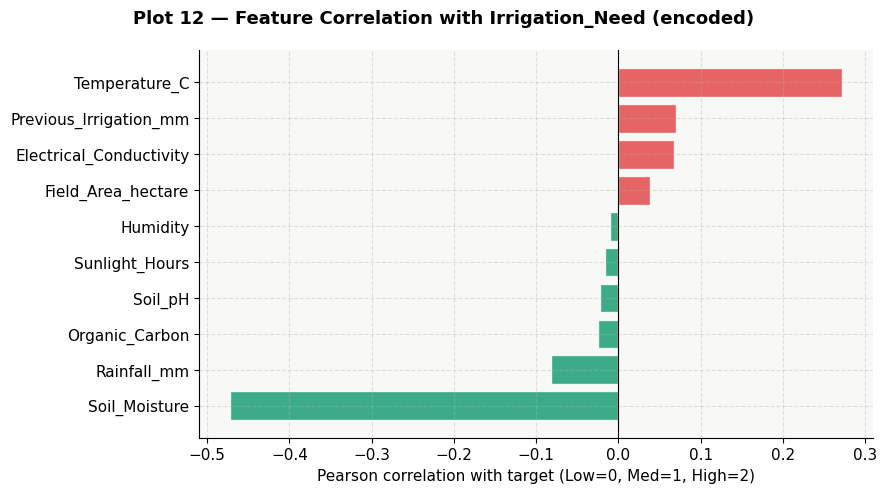

In [191]:
target_enc = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
corrs = df[NUMERIC].corrwith(target_enc).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Plot 12 — Feature Correlation with Irrigation_Need (encoded)', fontsize=13, fontweight='bold')

colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with target (Low=0, Med=1, High=2)')

plt.tight_layout()
plt.savefig('plot12_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


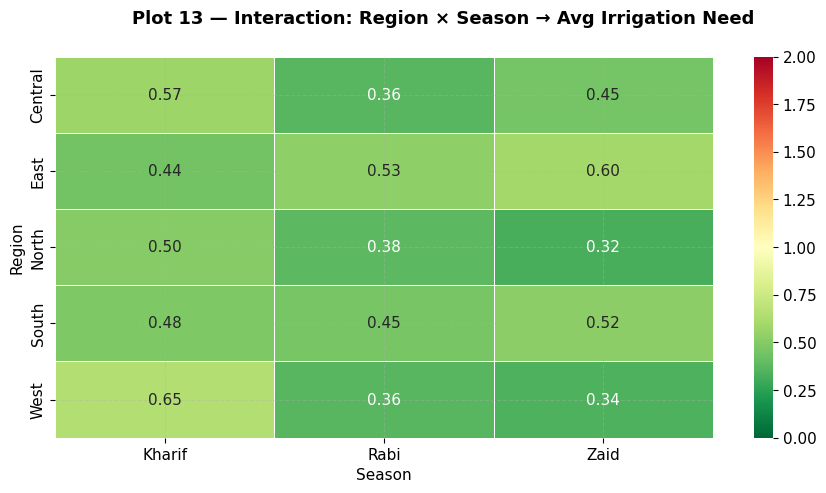

In [192]:
target_enc_series = df[TARGET].map({'Low': 0, 'Medium': 1, 'High': 2})
pivot = df.copy()
pivot['target_enc'] = target_enc_series
heat = pivot.groupby(['Region', 'Season'])['target_enc'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Plot 13 — Interaction: Region × Season → Avg Irrigation Need', fontsize=13, fontweight='bold')
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=2)
ax.set_xlabel('Season')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('plot13_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

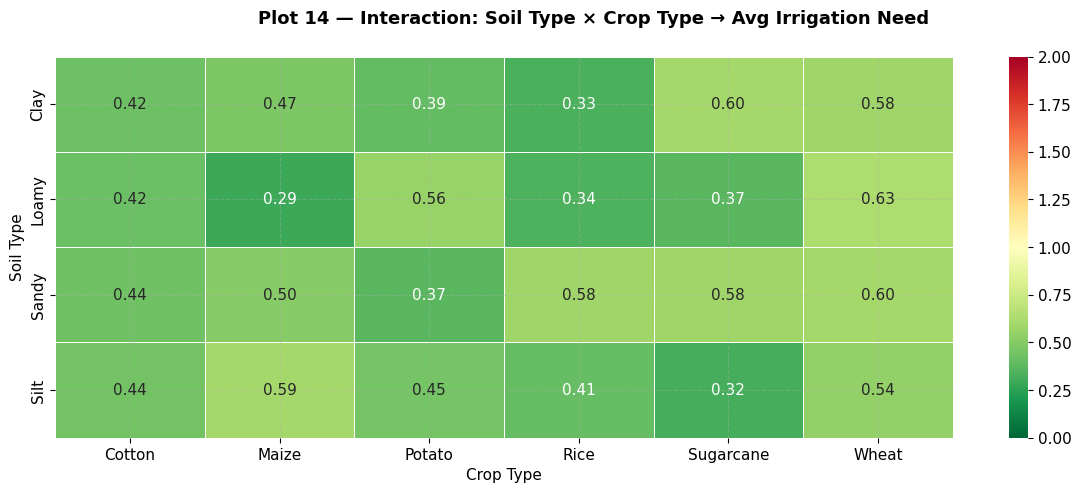

In [193]:
pivot2 = df.copy()
pivot2['target_enc'] = target_enc_series
heat2 = pivot2.groupby(['Soil_Type', 'Crop_Type'])['target_enc'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Plot 14 — Interaction: Soil Type × Crop Type → Avg Irrigation Need', fontsize=13, fontweight='bold')
sns.heatmap(heat2, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=2)
ax.set_xlabel('Crop Type')
ax.set_ylabel('Soil Type')
plt.tight_layout()
plt.savefig('plot14_soil_crop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [194]:
# import shap

# # Use the random forest from Plot 11 (or replace with your best model)
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X)

# # For multi-class, shap_values is a list [class0, class1, class2]
# # Plot for class 'High' (index 2 after LabelEncoding)
# plt.figure(figsize=(10, 7))
# shap.summary_plot(shap_values[2], X, plot_type='dot',
#                   show=False, max_display=15)
# plt.title('Plot 15 — SHAP Summary (class: High irrigation need)', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.savefig('plot15_shap.png', dpi=150, bbox_inches='tight')
# plt.show()

In [195]:
print("\n" + "="*60)
print("  EDA COMPLETE — KEY DECISIONS CHECKLIST")
print("="*60)
print(f"  Rows          : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")
print(f"  Numeric feats : {len(NUMERIC)}")
print(f"  Categorical   : {len(CATEGORICAL)}")
print(f"\n  Target distribution:")
for cls in ORDER:
    n = (df[TARGET] == cls).sum()
    print(f"    {cls:8s}: {n:5d}  ({n/len(df)*100:.1f}%)")
print(f"\n  Missing values: {df.isnull().sum().sum()} total cells")
print(f"\n  High-skew features (|skew|>1):")
for col in NUMERIC:
    s = skew(df[col].dropna())
    if abs(s) > 1:
        print(f"    {col} → log1p transform recommended")
print("\n" + "="*60)


  EDA COMPLETE — KEY DECISIONS CHECKLIST
  Rows          : 1,000
  Columns       : 21
  Numeric feats : 10
  Categorical   : 8

  Target distribution:
    Low     :   582  (58.2%)
    Medium  :   364  (36.4%)
    High    :    54  (5.4%)

  Missing values: 0 total cells

  High-skew features (|skew|>1):



## Feature Engineering

In [196]:
mapper = {
    'Low' : 0,
    'Medium': 1,
    'High': 2
}
train_df['Irrigation_Need'] = train_df['Irrigation_Need'].map(mapper)

print(train_df['Irrigation_Need'].unique())

[0 1 2]


In [197]:
train_df.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [198]:
features = train_df.select_dtypes(include='number').columns.tolist()
for i in ['id', 'Irrigation_Need']:
    features.remove(i)
features

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [199]:
print(f'Uniques values of Seasons: {train_df['Season'].unique()}') # we have to give them some different weight because they need different amount of irrigation but don't do this ever because this reduces generalization and introduces bias and lead to overfitting
print(f'Uniques values of Crop_Growth_Stage: {train_df['Crop_Growth_Stage'].unique()}')

Uniques values of Seasons: ['Zaid' 'Kharif' 'Rabi']
Uniques values of Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']


In [200]:
train_df[['Crop_Growth_Stage', 'Irrigation_Need']].head()

,Crop_Growth_Stage,Irrigation_Need
0,Sowing,0
1,Vegetative,0
2,Vegetative,0
3,Flowering,1
4,Sowing,0


In [201]:
train_df.groupby('Crop_Growth_Stage')['Irrigation_Need'].sum()

Crop_Growth_Stage
Flowering     119497
Harvest        26036
Sowing         19144
Vegetative    116415
Name: Irrigation_Need, dtype: int64

In [202]:
for df in [train_df, test_df]:
    # due to index misalignment between train and test DataFrames.
    df['Total_Irrigation_Need'] = df[features].sum(axis=1)
    df['Irrigation_Need_Std'] = df[features].std(axis=1)
    df['Irrigation_Need_Mean'] = df[features].mean(axis=1)
    df['Irrigation_Need_Median'] = df[features].median(axis=1)
    df['Irrigation_Need_Min'] = df[features].min(axis=1)
    df['Irrigation_Need_Max'] = df[features].max(axis=1)
    df['Irrigation_Need_Skew'] = df[features].skew(axis=1)
    df['Irrigation_Need_Kurtosis'] = df[features].kurtosis(axis=1)
    df['Irrigation_Need_CV'] = df['Irrigation_Need_Std'] / (df['Irrigation_Need_Mean'] * 1e-6)
    
    # Percentile-Based Features
    df['Irrigation_Need_25'] = df[features].quantile(0.25, axis=1)
    df['Irrigation_Need_75'] = df[features].quantile(0.75, axis=1)
    df['Irrigation_Need_IQR'] = df['Irrigation_Need_75'] - df['Irrigation_Need_25']      # not a useful feature only 0.07.. correlation

In [203]:
features

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [288]:
Weather_effects_loss = ['Temperature_C', 'Sunlight_Hours','Wind_Speed_kmh']
Weather_effects_gain = ['Humidity', 'Rainfall_mm']
Soil_effects = ['Soil_pH', 'Soil_Moisture', 'Electrical_Conductivity', 'Organic_Carbon']
Human_effects = ['Previous_Irrigation_mm', 'Field_Area_hectare']

for df in [train_df, test_df]:
    df['Weather_effects_loss'] = df[Weather_effects_loss].sum(axis=1)
    df['Weather_effects_gain'] = df[Weather_effects_gain].sum(axis=1)
    df['Soil_effects'] = df[Soil_effects].sum(axis=1)
    df['Human_effects'] = df[Human_effects].sum(axis=1)
    df['Net_Weather_Stress'] = df['Weather_effects_loss'] - df['Weather_effects_gain']

In [289]:
for df in [train_df, test_df]:
    df['Soil_Moisture_X_Temperature'] = df['Soil_Moisture'] * df['Temperature_C']
    df['Humidity_X_Rainfall_mm'] = df['Humidity'] * df['Rainfall_mm']
    df['Soil_Moisture_D_Sunlight_Hours'] = df['Soil_Moisture'] / df['Sunlight_Hours']
    df['Sunlight_Hours_X_Temperature'] = df['Sunlight_Hours'] * df['Temperature_C']
    df['Field_Area_hectare_X_Previous_Irrigation_mm'] = df['Field_Area_hectare'] * df['Previous_Irrigation_mm']
    df['Wind_Speed_kmh_X_Temperature_C'] = df['Wind_Speed_kmh'] * df['Temperature_C']
    df['Organic_Carbon_X_Field_Area_hectare'] = df['Organic_Carbon'] * df['Soil_pH']
    df['Wind_X_SoilMoisture'] = df['Wind_Speed_kmh'] * df['Soil_Moisture']
    df['OrgCarbon_X_SoilpH']  = df['Organic_Carbon'] * df['Soil_pH']

In [290]:
for df in [train_df, test_df]:
    df['Rain_per_SunHour']    = df['Rainfall_mm'] / (df['Sunlight_Hours'] + 1)
    df['Humidity_per_Temp']   = df['Humidity']    / (df['Temperature_C']  + 1)
    df['SoilMoist_per_Temp']  = df['Soil_Moisture'] / (df['Temperature_C'] + 1)

In [291]:
print(f'Weater_effect_loss:\n\tMin: {train_df['Weather_effects_loss'].min()}\n\tMedian: {train_df['Weather_effects_loss'].median()}\n\tMax: {train_df['Weather_effects_loss'].max()}')

print(f'Wind_Speed_kmh_X_Soil_Moisture:\n\tMin: {train_df['Wind_Speed_kmh_X_Soil_Moisture'].min()}\n\tMedian: {train_df['Wind_Speed_kmh_X_Soil_Moisture'].median()}\n\tMax: {train_df['Wind_Speed_kmh_X_Soil_Moisture'].max()}')

print(f'Weater_effects_loss:\n\tMin: {train_df['Sunlight_Hours_X_Temperature'].min()}\n\tMedian: {train_df['Sunlight_Hours_X_Temperature'].median()}\n\tMax: {train_df['Sunlight_Hours_X_Temperature'].max()}')

Weater_effect_loss:
	Min: 0.026783882783882718
	Median: 1.5112802197802198
	Max: 2.9706923076923073
Wind_Speed_kmh_X_Soil_Moisture:
	Min: 0.0
	Median: 0.29146506274009
	Max: 0.9999999999999999
Weater_effects_loss:
	Min: 0.0
	Median: 0.189102619047619
	Max: 0.9982385714285712


In [292]:
for df in [train_df, test_df]:
    df['ET_proxy'] = df['Temperature_C'] * df['Sunlight_Hours']

In [293]:
train_df['ET_proxy'].head()

0    0.027233
1    0.154960
2    0.146136
3    0.032183
4    0.115471
Name: ET_proxy, dtype: float64

In [294]:
for df in [train_df, test_df]:
    df['High_Irrigation_Need'] = (df['ET_proxy'] + df['Wind_X_SoilMoisture']) / (df['Rainfall_mm'] + 1)

    df['Low_Irrigation_Need'] = df[['Soil_Moisture', 'Rainfall_mm']].sum(axis=1)
    
    df['Medium_Irrigation_Need'] = df[['High_Irrigation_Need', 'Low_Irrigation_Need']].mean(axis=1)

In [296]:
corrlation_matrix = train_df.select_dtypes(include='number').corr()['Irrigation_Need'].sort_values(ascending=False)
print(corrlation_matrix)

Irrigation_Need                   1.000000
Wind_Speed_kmh_X_Temperature_C    0.348347
Wind_Speed_kmh_X_Soil_Moisture    0.347030
Crop_Growth_Stage_Flowering       0.321888
Crop_Growth_Stage_Vegetative      0.302851
                                    ...   
Medium_Irrigation_Need           -0.318212
Soil_Moisture_X_Sunlight_Hours   -0.378341
Low_Irrigation_Need              -0.409918
Soil_Moisture                    -0.455482
SoilMoist_per_Temp               -0.486116
Name: Irrigation_Need, Length: 79, dtype: float64


### Filtering Numerical and Categorcial Columns for Scaling and Categorical Columns

In [219]:
train_df = train_df.drop('id', axis=1)

test_id = test_df['id']
test_df = test_df.drop('id', axis=1)

test_df.size

14040000

In [220]:
print('All columns:\n{train_df.columns}')

# Selecting columns for train_df
train_num_cols = train_df.select_dtypes(include='number').columns.to_list()
train_num_cols.remove('Irrigation_Need')
print(f'\nNumerical Columns:\n{train_num_cols}')

train_cat_cols = train_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{train_cat_cols}')

# Selecting columns for test_df
test_num_cols = test_df.select_dtypes(include='number').columns.to_list()
print(f'\nNumerical Columns:\n{test_num_cols}')

test_cat_cols = test_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{test_cat_cols}')

All columns:
{train_df.columns}

Numerical Columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Total_Irrigation_Need', 'Irrigation_Need_Std', 'Irrigation_Need_Mean', 'Irrigation_Need_Median', 'Irrigation_Need_Min', 'Irrigation_Need_Max', 'Irrigation_Need_Skew', 'Irrigation_Need_Kurtosis', 'Irrigation_Need_CV', 'Irrigation_Need_25', 'Irrigation_Need_75', 'Irrigation_Need_IQR', 'Weather_effects_loss', 'Weather_effects_gain', 'Soil_effects', 'Human_effects', 'Net_Weather_Stress', 'Soil_Moisture_X_Temperature', 'Humidity_X_Rainfall_mm', 'Soil_Moisture_X_Sunlight_Hours', 'Sunlight_Hours_X_Temperature', 'Field_Area_hectare_X_Previous_Irrigation_mm', 'Wind_Speed_kmh_X_Soil_Moisture', 'Organic_Carbon_X_Field_Area_hectare', 'Wind_X_SoilMoisture', 'OrgCarbon_X_SoilpH', 'Rain_per_SunHour', 'Humidity_per_Temp', 'SoilMoist_per_Temp', 'ET_pro

## Scaling Dataset

In [221]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(train_df[train_num_cols])

In [222]:
train_df[train_num_cols] = scaler.transform(train_df[train_num_cols])
test_df[test_num_cols] = scaler.transform(test_df[test_num_cols])

In [223]:
train_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Organic_Carbon_X_Field_Area_hectare,Wind_X_SoilMoisture,OrgCarbon_X_SoilpH,Rain_per_SunHour,Humidity_per_Temp,SoilMoist_per_Temp,ET_proxy,High_Irrigation_Need,Low_Irrigation_Need,Medium_Irrigation_Need
0,Loamy,0.035294,0.431304,0.546154,0.867647,0.100333,0.365909,0.290324,0.271429,0.835385,...,0.302865,0.419817,0.302865,0.211003,0.384274,0.384781,0.097920,0.002394,0.292837,0.288867
1,Clay,0.670588,0.852957,0.107692,0.558824,0.364000,0.612373,0.394221,0.425714,0.148205,...,0.143354,0.145270,0.143354,0.247721,0.335902,0.453830,0.270693,0.000931,0.403926,0.400393
2,Clay,0.261765,0.345850,0.392308,0.802941,0.499000,0.960423,0.880771,0.292857,0.171795,...,0.271866,0.079380,0.271866,0.626499,0.404559,0.167370,0.278402,0.000269,0.868776,0.867834
3,Sandy,0.250000,0.093350,0.792308,0.226471,0.044000,0.522503,0.542930,0.731429,0.092821,...,0.521853,0.020688,0.521853,0.269004,0.554136,0.154767,0.177552,0.000239,0.532510,0.529623
4,Clay,0.929412,0.897350,0.061538,0.252941,0.274000,0.944564,0.615298,0.421429,0.689231,...,0.135576,0.634278,0.135576,0.388108,0.553242,0.541346,0.223636,0.001695,0.621276,0.619103


In [224]:
test_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Organic_Carbon_X_Field_Area_hectare,Wind_X_SoilMoisture,OrgCarbon_X_SoilpH,Rain_per_SunHour,Humidity_per_Temp,SoilMoist_per_Temp,ET_proxy,High_Irrigation_Need,Low_Irrigation_Need,Medium_Irrigation_Need
0,Silt,0.458824,0.319179,0.223077,0.797059,0.194333,0.074868,0.613369,0.200000,0.128205,...,0.198176,0.057645,0.198176,0.480617,0.152226,0.250681,0.116602,0.000245,0.606486,0.604026
1,Clay,0.314706,0.032988,0.676923,0.929412,0.306000,0.758251,0.230332,0.460000,0.788718,...,0.471272,0.118200,0.471272,0.140503,0.437792,0.053851,0.253609,0.001440,0.225236,0.220743
2,Sandy,0.417647,0.325496,0.507692,0.220588,0.495667,0.505072,0.218028,0.775714,0.109231,...,0.389073,0.050885,0.389073,0.104794,0.235702,0.159445,0.496635,0.001595,0.219723,0.215219
3,Clay,0.847059,0.799789,0.407692,0.132353,0.991333,0.157880,0.484394,0.384286,0.069744,...,0.423763,0.073949,0.423763,0.315870,0.038459,0.222109,0.559183,0.000806,0.490988,0.487940
4,Loamy,0.126471,0.895245,0.184615,0.591176,0.969333,0.392485,0.528758,0.015714,0.267179,...,0.118317,0.257448,0.118317,0.518940,0.098655,0.253117,0.292118,0.001003,0.536536,0.533778


## Imputing the Categorical Columns

In [225]:
from sklearn.preprocessing import OneHotEncoder

In [226]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[train_cat_cols])

In [227]:
encoded_cols = encoder.get_feature_names_out().tolist()
encoded_cols, type(encoded_cols)

(['Soil_Type_Clay',
  'Soil_Type_Loamy',
  'Soil_Type_Sandy',
  'Soil_Type_Silt',
  'Crop_Type_Cotton',
  'Crop_Type_Maize',
  'Crop_Type_Potato',
  'Crop_Type_Rice',
  'Crop_Type_Sugarcane',
  'Crop_Type_Wheat',
  'Crop_Growth_Stage_Flowering',
  'Crop_Growth_Stage_Harvest',
  'Crop_Growth_Stage_Sowing',
  'Crop_Growth_Stage_Vegetative',
  'Season_Kharif',
  'Season_Rabi',
  'Season_Zaid',
  'Irrigation_Type_Canal',
  'Irrigation_Type_Drip',
  'Irrigation_Type_Rainfed',
  'Irrigation_Type_Sprinkler',
  'Water_Source_Groundwater',
  'Water_Source_Rainwater',
  'Water_Source_Reservoir',
  'Water_Source_River',
  'Mulching_Used_No',
  'Mulching_Used_Yes',
  'Region_Central',
  'Region_East',
  'Region_North',
  'Region_South',
  'Region_West'],
 list)

In [228]:
train_df[encoded_cols] = encoder.transform(train_df[train_cat_cols])
test_df[encoded_cols] = encoder.transform(test_df[test_cat_cols])

In [229]:
train_df.columns, test_df.columns

(Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
        'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
        'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
        'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
        'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
        'Total_Irrigation_Need', 'Irrigation_Need_Std', 'Irrigation_Need_Mean',
        'Irrigation_Need_Median', 'Irrigation_Need_Min', 'Irrigation_Need_Max',
        'Irrigation_Need_Skew', 'Irrigation_Need_Kurtosis',
        'Irrigation_Need_CV', 'Irrigation_Need_25', 'Irrigation_Need_75',
        'Irrigation_Need_IQR', 'Weather_effects_loss', 'Weather_effects_gain',
        'Soil_effects', 'Human_effects', 'Net_Weather_Stress',
        'Soil_Moisture_X_Temperature', 'Humidity_X_Rainfall_mm',
        'Soil_Moisture_X_Sunlight_Hours', 'Sunlight_Hours_X_Temperature',
        'Field_Area_hectare_X_Previous_Irrigat

In [230]:
for col in train_df.columns:
    print(f'{col}: {train_df[col].dtype}')

Soil_Type: object
Soil_pH: float64
Soil_Moisture: float64
Organic_Carbon: float64
Electrical_Conductivity: float64
Temperature_C: float64
Humidity: float64
Rainfall_mm: float64
Sunlight_Hours: float64
Wind_Speed_kmh: float64
Crop_Type: object
Crop_Growth_Stage: object
Season: object
Irrigation_Type: object
Water_Source: object
Field_Area_hectare: float64
Mulching_Used: object
Previous_Irrigation_mm: float64
Region: object
Irrigation_Need: int64
Total_Irrigation_Need: float64
Irrigation_Need_Std: float64
Irrigation_Need_Mean: float64
Irrigation_Need_Median: float64
Irrigation_Need_Min: float64
Irrigation_Need_Max: float64
Irrigation_Need_Skew: float64
Irrigation_Need_Kurtosis: float64
Irrigation_Need_CV: float64
Irrigation_Need_25: float64
Irrigation_Need_75: float64
Irrigation_Need_IQR: float64
Weather_effects_loss: float64
Weather_effects_gain: float64
Soil_effects: float64
Human_effects: float64
Net_Weather_Stress: float64
Soil_Moisture_X_Temperature: float64
Humidity_X_Rainfall_mm: 

### Final training and test datasets

In [231]:
input_cols = train_num_cols + encoded_cols
target_col = 'Irrigation_Need'

In [232]:
input_df = train_df[train_num_cols + encoded_cols]
test_df = test_df[test_num_cols + encoded_cols]

In [233]:
input_df.columns, test_df.columns

(Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
        'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
        'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
        'Total_Irrigation_Need', 'Irrigation_Need_Std', 'Irrigation_Need_Mean',
        'Irrigation_Need_Median', 'Irrigation_Need_Min', 'Irrigation_Need_Max',
        'Irrigation_Need_Skew', 'Irrigation_Need_Kurtosis',
        'Irrigation_Need_CV', 'Irrigation_Need_25', 'Irrigation_Need_75',
        'Irrigation_Need_IQR', 'Weather_effects_loss', 'Weather_effects_gain',
        'Soil_effects', 'Human_effects', 'Net_Weather_Stress',
        'Soil_Moisture_X_Temperature', 'Humidity_X_Rainfall_mm',
        'Soil_Moisture_X_Sunlight_Hours', 'Sunlight_Hours_X_Temperature',
        'Field_Area_hectare_X_Previous_Irrigation_mm',
        'Wind_Speed_kmh_X_Soil_Moisture', 'Organic_Carbon_X_Field_Area_hectare',
        'Wind_X_SoilMoisture', 'OrgCarbon_X_SoilpH', 'Rain_per_S

In [234]:
test_df.size

20520000

## Train/Val Split and Test Input and Target

In [235]:
from sklearn.model_selection import train_test_split

X_train, X_val , Y_train, Y_val = train_test_split(input_df[input_cols],
                                                   train_df[target_col],
                                                   test_size=0.2,
                                                   random_state=231)

## Training Models

In [236]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [237]:
def get_accuracy(Y_train, Y_val, train_pred, val_pred):
    train_acc = accuracy_score(Y_train, train_pred)
    val_acc = accuracy_score(Y_val, val_pred)

    train_prec = precision_score(Y_train, train_pred, average='weighted')
    val_prec = precision_score(Y_val, val_pred, average='weighted')

    train_rec = recall_score(Y_train, train_pred, average='weighted')
    val_rec = recall_score(Y_val, val_pred, average='weighted')

    train_f1 = f1_score(Y_train, train_pred, average='weighted')
    val_f1 = f1_score(Y_val, val_pred, average='weighted')

    print(f'Train accuracy score: {train_acc}')
    print(f'Val accuracy score: {val_acc}\n')

    print(f'Train precision score: {train_prec}')
    print(f'val precision score: {val_prec}\n')

    print(f'Train recall score: {train_rec}')
    print(f'val recall score: {val_rec}\n')

    print(f'Train f1 score: {train_f1}')
    print(f'val f1 score: {val_f1}\n')

### LightGBM Model

In [297]:
import lightgbm
from lightgbm import early_stopping, log_evaluation

In [298]:
lgbm_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'random_state': 523,
    'n_jobs': -1
}

lgbm = lightgbm.LGBMClassifier(**lgbm_params)

In [ ]:
lgbm.fit(X_train, Y_train,
         eval_set=[(X_val, Y_val)],
         callbacks=[
            early_stopping(stopping_rounds=100,),
            log_evaluation(period=50)
        ])

Training until validation scores don't improve for 100 rounds
[50]	valid_0's multi_logloss: 0.103563
[100]	valid_0's multi_logloss: 0.0680277
[150]	valid_0's multi_logloss: 0.0628561
[200]	valid_0's multi_logloss: 0.0606994
[250]	valid_0's multi_logloss: 0.0595927
[300]	valid_0's multi_logloss: 0.058937
[350]	valid_0's multi_logloss: 0.0585676
[400]	valid_0's multi_logloss: 0.0582204
[450]	valid_0's multi_logloss: 0.0579563
[500]	valid_0's multi_logloss: 0.0577983
[550]	valid_0's multi_logloss: 0.0576663
[600]	valid_0's multi_logloss: 0.0575502
[650]	valid_0's multi_logloss: 0.0574628
[700]	valid_0's multi_logloss: 0.0574185
[750]	valid_0's multi_logloss: 0.0573467
[800]	valid_0's multi_logloss: 0.0573259
[850]	valid_0's multi_logloss: 0.0573213
[900]	valid_0's multi_logloss: 0.0573381
[950]	valid_0's multi_logloss: 0.0573245
Early stopping, best iteration is:
[864]	valid_0's multi_logloss: 0.0573065


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [241]:
train_pred = lgbm.predict(X_train)
val_pred = lgbm.predict(X_val)

In [242]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9890595238095238
Val accuracy score: 0.9847539682539682

Train precision score: 0.9890787049781394
val precision score: 0.984711209814877

Train recall score: 0.9890595238095238
val recall score: 0.9847539682539682

Train f1 score: 0.9890416233390696
val f1 score: 0.9846864416268719



In [ ]:
# ─────────────────────────────────────────────
# SUBMISSION
# ─────────────────────────────────────────────
submission = pd.DataFrame({
    'id': test_id.reset_index(drop=True),
    'Irrigation_Need': pd.Series(final_test_pred).map(MAPPER)
})

SUBMISSION_PATH = r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Codes\submission_files\Irrigation_Prediction_Submission_Files\Irrigation_Prediction_Lgbm_M2.csv'

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\n  Submission saved → {SUBMISSION_PATH}")
print(f"  Shape : {submission.shape}")
print(submission.head(10))
print("\nLabel distribution:")
print(submission['Irrigation_Need'].value_counts())

# XGBoost

In [243]:
import xgboost

In [244]:
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'n_jobs': -1
}
xgbc = xgboost.XGBClassifier(**xgb_params)

In [247]:
xgbc.fit(X_train, Y_train, 
        eval_set=[(X_val, Y_val)],
        verbose=100)

[0]	validation_0-mlogloss:0.90985
[100]	validation_0-mlogloss:0.07058
[200]	validation_0-mlogloss:0.06168
[300]	validation_0-mlogloss:0.05982
[400]	validation_0-mlogloss:0.05897
[500]	validation_0-mlogloss:0.05856
[600]	validation_0-mlogloss:0.05842
[700]	validation_0-mlogloss:0.05836
[800]	validation_0-mlogloss:0.05836
[900]	validation_0-mlogloss:0.05851
[999]	validation_0-mlogloss:0.05875


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [248]:
train_pred = xgbc.predict(X_train)
val_pred = xgbc.predict(X_val)

In [249]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9937242063492063
Val accuracy score: 0.9842063492063492

Train precision score: 0.9937342039078549
val precision score: 0.9841623311125799

Train recall score: 0.9937242063492063
val recall score: 0.9842063492063492

Train f1 score: 0.993719317593416
val f1 score: 0.9841315746431901



## Random Forest Classifier

In [250]:
from sklearn.ensemble import RandomForestClassifier

In [262]:
rf_params = {
    'n_estimators': 200,
    'max_depth': 7,
    'min_samples_split': 7,
    'min_samples_leaf': 4,
    'max_features': 0.8,
    'verbose': 2,
    'n_jobs': -1
    
}
rfc = RandomForestClassifier(**rf_params)

In [263]:
rfc.fit(X_train, Y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 200building tree 2 of 200
building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200

building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200building tree 21 of 200

building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  1.0min


building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200
building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71

[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  6.3min


building tree 151 of 200
building tree 152 of 200
building tree 153 of 200
building tree 154 of 200
building tree 155 of 200
building tree 156 of 200
building tree 157 of 200
building tree 158 of 200
building tree 159 of 200
building tree 160 of 200
building tree 161 of 200
building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  8.8min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [264]:
train_pred = rfc.predict(X_train)
val_pred = rfc.predict(X_val)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    2.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.5s finished


In [265]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.9802559523809524
Val accuracy score: 0.979468253968254

Train precision score: 0.980149992959363
val precision score: 0.9793694487588628

Train recall score: 0.9802559523809524
val recall score: 0.979468253968254

Train f1 score: 0.9799832946896965
val f1 score: 0.9791652517127422



## Logistic Regression

In [269]:
from sklearn.linear_model import LogisticRegression

In [272]:
lr_params = {
    'C': 0.1,
    'penalty': 'l2',
    'solver': 'liblinear'
}
lr = LogisticRegression(**lr_params).fit(X_train, Y_train)

c:\Users\itspr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

In [ ]:
train_pred = lr.predict(X_train)
val_pred = lr.predict(X_val)

In [ ]:
get_accuracy(Y_train, Y_val, train_pred, val_pred)

Train accuracy score: 0.8864067460317461
Val accuracy score: 0.8856984126984127

Train precision score: 0.8863116460970124
val precision score: 0.8855928759703007

Train recall score: 0.8864067460317461
val recall score: 0.8856984126984127

Train f1 score: 0.8859920739644549
val f1 score: 0.8853018051959595



## Training the Model usnig K-fold cross validation

In [273]:
from sklearn.model_selection import StratifiedKFold
import joblib

In [274]:
# CONFIG

N_SPLITS    = 5
RANDOM_STATE = 523

MAPPER = {0: 'Low', 1: 'Medium', 2: 'High'}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# ─────────────────────────────────────────────
# MODEL DEFINITIONS
# ─────────────────────────────────────────────
lgbm_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
}

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'n_jobs': -1,
    'eval_metric': 'mlogloss',
    'early_stopping_rounds': 100,
    'random_state': RANDOM_STATE,
}

rf_params = {
    'n_estimators': 70,
    'max_depth': 7,
    'min_samples_split': 7,
    'min_samples_leaf': 4,
    'max_features': 0.8,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}


In [280]:
# K-FOLD RUNNER

def run_kfold(name, model_fn, X, Y, X_test, fit_kwargs_fn=None):
    """
    Runs StratifiedKFold, collects OOF predictions + test fold predictions.
    model_fn      : callable that returns a fresh model instance each fold
    fit_kwargs_fn : callable(model, X_tr, Y_tr, X_val, Y_val) → dict of extra fit kwargs
    Returns       : oof_preds (N,), test_preds (N_test,), fold_metrics list
    """
    oof_preds   = np.zeros(len(X), dtype=int)
    test_preds  = np.zeros((len(X_test), N_SPLITS), dtype=int)
    fold_metrics = []

    print(f"\n{'='*55}")
    print(f"  {name}  —  {N_SPLITS}-Fold Cross Validation")
    print(f"{'='*55}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, Y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        Y_tr, Y_val = Y.iloc[tr_idx], Y.iloc[val_idx]

        model = model_fn()
        extra = fit_kwargs_fn(model, X_tr, Y_tr, X_val, Y_val) if fit_kwargs_fn else {}
        model.fit(X_tr, Y_tr, **extra)

        val_pred  = model.predict(X_val)
        oof_preds[val_idx] = val_pred

        test_preds[:, fold - 1] = model.predict(X_test)

        acc = accuracy_score(Y_val, val_pred)
        f1  = f1_score(Y_val, val_pred, average='weighted')
        fold_metrics.append({'fold': fold, 'acc': acc, 'f1': f1})
        print(f"  Fold {fold}  →  Acc: {acc:.4f}  |  F1: {f1:.4f}")

    oof_acc = accuracy_score(Y, oof_preds)
    oof_f1  = f1_score(Y, oof_preds, average='weighted')
    print(f"\n  OOF Acc : {oof_acc:.4f}  |  OOF F1: {oof_f1:.4f}")

    # majority vote across folds for test
    from scipy import stats
    final_test_preds, _ = stats.mode(test_preds, axis=1)
    final_test_preds = final_test_preds.flatten().astype(int)

    return oof_preds, final_test_preds, fold_metrics, oof_f1



In [281]:
# LGBM FIT KWARGS (early stopping needs eval_set)

def lgbm_fit_kwargs(model, X_tr, Y_tr, X_val, Y_val):
    return {
        'eval_set': [(X_val, Y_val)],
        'callbacks': [early_stopping(100, verbose=False), log_evaluation(period=0)],
    }

def xgb_fit_kwargs(model, X_tr, Y_tr, X_val, Y_val):
    return {
        'eval_set': [(X_val, Y_val)],
        'verbose': False,
    }


In [282]:
# RUN ALL THREE MODELS

# Combine train + val back into a single frame for K-Fold

X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
Y_full = pd.concat([Y_train, Y_val], axis=0).reset_index(drop=True)

lgbm_oof, lgbm_test, lgbm_metrics, lgbm_f1 = run_kfold(
    "LightGBM",
    lambda: lightgbm.LGBMClassifier(**lgbm_params),
    X_full, Y_full, test_df,
    fit_kwargs_fn=lgbm_fit_kwargs
)

xgb_oof, xgb_test, xgb_metrics, xgb_f1 = run_kfold(
    "XGBoost",
    lambda: xgboost.XGBClassifier(**xgb_params),
    X_full, Y_full, test_df,
    fit_kwargs_fn=xgb_fit_kwargs
)

rf_oof, rf_test, rf_metrics, rf_f1 = run_kfold(
    "Random Forest",
    lambda: RandomForestClassifier(**rf_params),
    X_full, Y_full, test_df,
)


  LightGBM  —  5-Fold Cross Validation
  Fold 1  →  Acc: 0.9845  |  F1: 0.9844
  Fold 2  →  Acc: 0.9851  |  F1: 0.9850
  Fold 3  →  Acc: 0.9846  |  F1: 0.9845
  Fold 4  →  Acc: 0.9850  |  F1: 0.9849
  Fold 5  →  Acc: 0.9852  |  F1: 0.9852

  OOF Acc : 0.9849  |  OOF F1: 0.9848

  XGBoost  —  5-Fold Cross Validation
  Fold 1  →  Acc: 0.9846  |  F1: 0.9845
  Fold 2  →  Acc: 0.9859  |  F1: 0.9858
  Fold 3  →  Acc: 0.9842  |  F1: 0.9841
  Fold 4  →  Acc: 0.9845  |  F1: 0.9844
  Fold 5  →  Acc: 0.9851  |  F1: 0.9851

  OOF Acc : 0.9849  |  OOF F1: 0.9848

  Random Forest  —  5-Fold Cross Validation
  Fold 1  →  Acc: 0.9386  |  F1: 0.9341
  Fold 2  →  Acc: 0.9379  |  F1: 0.9335
  Fold 3  →  Acc: 0.9402  |  F1: 0.9357
  Fold 4  →  Acc: 0.9390  |  F1: 0.9348
  Fold 5  →  Acc: 0.9393  |  F1: 0.9350

  OOF Acc : 0.9390  |  OOF F1: 0.9346


In [283]:
# ─────────────────────────────────────────────
# ENSEMBLE  —  weighted majority vote on test preds
# ─────────────────────────────────────────────
print(f"\n{'='*55}")
print("  OOF F1 scores (used as ensemble weights)")
print(f"  LGBM  : {lgbm_f1:.4f}")
print(f"  XGB   : {xgb_f1:.4f}")
print(f"  RF    : {rf_f1:.4f}")

# Stack test predictions and pick the model with highest OOF F1
all_test = np.stack([lgbm_test, xgb_test, rf_test], axis=1)   # (N_test, 3)
weights  = np.array([lgbm_f1, xgb_f1, rf_f1])
best_idx = np.argmax(weights)
names    = ["LightGBM", "XGBoost", "Random Forest"]

# Weighted majority vote
from scipy import stats
final_test_pred, _ = stats.mode(all_test, axis=1)
final_test_pred = final_test_pred.flatten().astype(int)

print(f"\n  Best single model : {names[best_idx]}  (F1={weights[best_idx]:.4f})")
print(f"  Final test preds use weighted majority vote across all three.")


  OOF F1 scores (used as ensemble weights)
  LGBM  : 0.9848
  XGB   : 0.9848
  RF    : 0.9346

  Best single model : LightGBM  (F1=0.9848)
  Final test preds use weighted majority vote across all three.


In [284]:
# ─────────────────────────────────────────────
# FINAL MODEL  —  retrain best model on ALL data
# ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Retraining {names[best_idx]} on full dataset …")

if best_idx == 0:
    final_model = lightgbm.LGBMClassifier(**{**lgbm_params, 'n_estimators': 500})
    final_model.fit(X_full, Y_full)
elif best_idx == 1:
    final_model = xgboost.XGBClassifier(**{k: v for k, v in xgb_params.items()
                                           if k != 'early_stopping_rounds'})
    final_model.fit(X_full, Y_full)
else:
    final_model = RandomForestClassifier(**rf_params)
    final_model.fit(X_full, Y_full)

MODEL_PATH  = r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Models\Irrigation_Prediction_Models\Irrigation_Prediction_K_Fold_Model3.pkl'

joblib.dump(final_model, MODEL_PATH)
print(f"  Model saved → {MODEL_PATH}")


  Retraining LightGBM on full dataset …
  Model saved → D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Models\Irrigation_Prediction_Models\Irrigation_Prediction_K_Fold_Model3.pkl


In [285]:
# ─────────────────────────────────────────────
# SUBMISSION
# ─────────────────────────────────────────────
submission = pd.DataFrame({
    'id': test_id.reset_index(drop=True),
    'Irrigation_Need': pd.Series(final_test_pred).map(MAPPER)
})

SUBMISSION_PATH = r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Codes\submission_files\Irrigation_Prediction_Submission_Files\Irrigation_Prediction_KFold_M3.csv'

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\n  Submission saved → {SUBMISSION_PATH}")
print(f"  Shape : {submission.shape}")
print(submission.head(10))
print("\nLabel distribution:")
print(submission['Irrigation_Need'].value_counts())


  Submission saved → D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Codes\submission_files\Irrigation_Prediction_Submission_Files\Irrigation_Prediction_KFold_M3.csv
  Shape : (270000, 2)
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low

Label distribution:
Irrigation_Need
Low       159865
Medium    101534
High        8601
Name: count, dtype: int64


test score = 0.94878 using k-fold 
test score = 0.95929 using lgbm without any feature engineering
test score = 0.94567 using lgbm with any feature engineering